In [1]:
#import the requried libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#load the dataset
data = pd.read_csv('Mall_Customers.csv')


In [3]:
#data preprocessing
data.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
#check information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
#check for missing values
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
#drop the 'CustomerID' column and gender column
data.drop(['CustomerID', 'Gender'], axis=1, inplace=True)

In [7]:
data.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


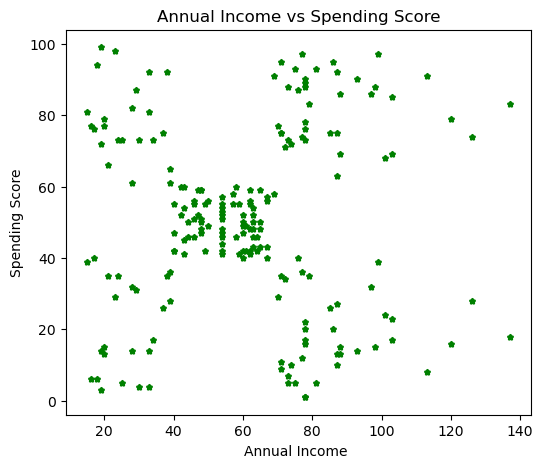

In [8]:
#EDA
#anual income vs spending scoreusing scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(x='Annual Income (k$)', 
                y='Spending Score (1-100)', 
                data=data,
                color='blue',             #color of the points
                edgecolor='green',        #color of the edges of the points
                alpha=1,                  #transparency of the points
                linewidth=2,              #width of the edges of the points
                marker='*',               #shape of the points
                s=10)
plt.title('Annual Income vs Spending Score')    
plt.xlabel('Annual Income ')
plt.ylabel('Spending Score')
plt.show() 

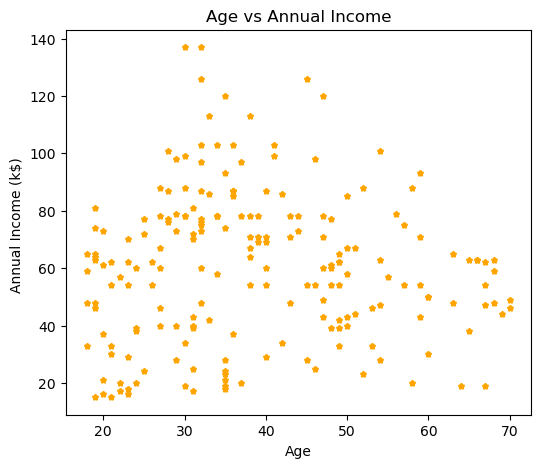

In [9]:
#EDA
#age vs anual income using scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(x='Age', 
                y='Annual Income (k$)', 
                data=data,
                color='black',             #color of the points
                edgecolor='orange',        #color of the edges of the points
                alpha=1,                  #transparency of the points
                linewidth=2,              #width of the edges of the points
                marker='*',               #shape of the points
                s=10)
plt.title('Age vs Annual Income')    
plt.xlabel('Age')
plt.ylabel('Annual Income (k$) ')
plt.show() 

In [11]:
## feature engineering
#standard scaler
from  sklearn.preprocessing  import StandardScaler
##load model
scaler=StandardScaler()
## fit model
scale_data=scaler.fit_transform(data)
print(scale_data)


[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]
 [-1.20926872 -1.66266033  1.00159627]
 [-0.27630176 -1.62449091 -1.71591298]
 [-1.13750203 -1.62449091  1.70038436]
 [ 1.80493225 -1.58632148 -1.83237767]
 [-0.6351352  -1.58632148  0.84631002]
 [ 2.02023231 -1.58632148 -1.4053405 ]
 [-0.27630176 -1.58632148  1.89449216]
 [ 1.37433211 -1.54815205 -1.36651894]
 [-1.06573534 -1.54815205  1.04041783]
 [-0.13276838 -1.54815205 -1.44416206]
 [-1.20926872 -1.54815205  1.11806095]
 [-0.27630176 -1.50998262 -0.59008772]
 [-1.3528021  -1.50998262  0.61338066]
 [ 0.94373197 -1.43364376 -0.82301709]
 [-0.27630176 -1.43364376  1.8556706 ]
 [-0.27630176 -1.39547433 -0.59008772]
 [-0.99396865 -1.39547433  0.88513158]
 [ 0.51313183 -1.3573049  -1.75473454]
 [-0.56336851 -1.3573049   0.88513158]
 [ 1.08726535 -1.24279661 -1.4053405 ]
 [-0.70690189 -1.24279661

In [13]:
## convert scale_data into data frame format
# Feature Engineering
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load scaler
scaler = StandardScaler()

# Fit and transform
scale_data = scaler.fit_transform(data)

# Convert to DataFrame
scaled_data = pd.DataFrame(scale_data, columns=data.columns)

print(scaled_data)

          Age  Annual Income (k$)  Spending Score (1-100)
0   -1.424569           -1.738999               -0.434801
1   -1.281035           -1.738999                1.195704
2   -1.352802           -1.700830               -1.715913
3   -1.137502           -1.700830                1.040418
4   -0.563369           -1.662660               -0.395980
..        ...                 ...                     ...
195 -0.276302            2.268791                1.118061
196  0.441365            2.497807               -0.861839
197 -0.491602            2.497807                0.923953
198 -0.491602            2.917671               -1.250054
199 -0.635135            2.917671                1.273347

[200 rows x 3 columns]


In [14]:
# Train Model
from sklearn.cluster import KMeans

# Load / Initialize the model
cluster = KMeans(n_clusters=3, random_state=42)

# Fit the model
cluster.fit(scaled_data)
# Train / Fit model
cluster.fit(scaled_data)
data["Cluster"]=cluster.labels_

c:\Users\gayat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gayat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [15]:
data["Cluster"].value_counts()

Cluster
0    96
2    63
1    41
Name: count, dtype: int64

NameError: name 'model' is not defined

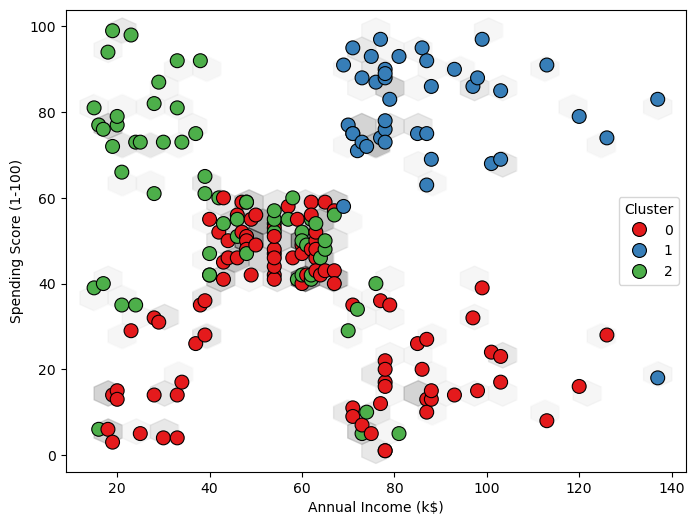

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,6))

# Hexbin background (density representation)
plt.hexbin(
    data["Annual Income (k$)"],
    data["Spending Score (1-100)"],
    gridsize=20,
    cmap="Greys",
    alpha=0.4
)

# Overlay cluster scatter
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    data=data,
    s=100,
    edgecolor="black"
)

# Plot centroids
centroids = model.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=350,
    c="gold",
    marker="X",
    label="Centroids"
)

plt.title("Advanced Cluster Visualization with Density Map", fontsize=14, fontweight="bold")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

NameError: name 'model' is not defined

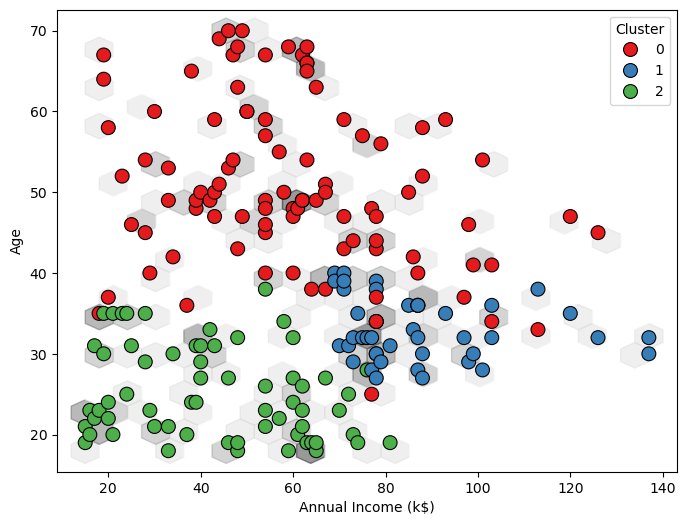

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,6))

# Hexbin background (density representation)
plt.hexbin(
    data["Annual Income (k$)"],
    data["Age"],
    gridsize=20,
    cmap="Greys",
    alpha=0.4
)

# Overlay cluster scatter
sns.scatterplot(
    x="Annual Income (k$)",
    y="Age",
    hue="Cluster",
    palette="Set1",
    data=data,
    s=100,
    edgecolor="black"
)

# Plot centroids
centroids = model.cluster_centers_
plt.scatter(
    centroids[:, 0],   # Income
    centroids[:, 1],   # Age (Make sure model was trained on Income & Age)
    s=350,
    c="gold",
    marker="X",
    label="Centroids"
)

plt.title("Cluster Visualization: Annual Income vs Age", fontsize=14, fontweight="bold")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Age")
plt.legend()
plt.show()

In [18]:
X = data[["Annual Income (k$)", "Age"]]

c:\Users\gayat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gayat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gayat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gayat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

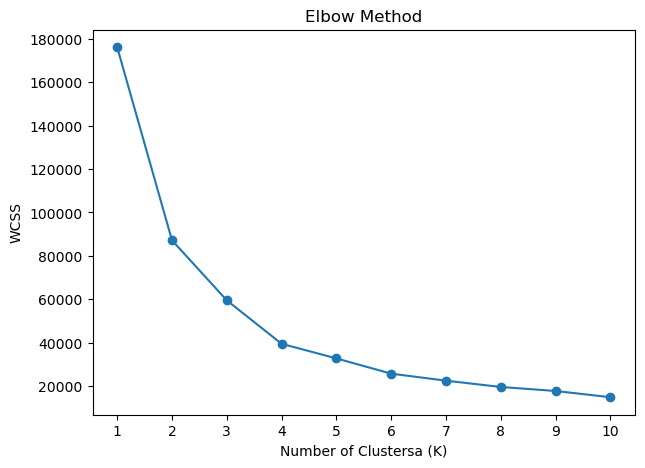

In [19]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []   # Within Cluster Sum of Squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)   # inertia = WCSS

# Plot
plt.figure(figsize=(7,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clustersa (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.show()

In [20]:
data.to_csv("customer_clustered_data.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Encode Gender
df['Gender'] = (df['Gender'] == 'Male').astype(int)

# Select 4 features
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
model = KMeans(n_clusters=5, random_state=42)
model.fit(X_scaled)

# Save
joblib.dump(model, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model retrained successfully!")

Model retrained successfully!


c:\Users\gayat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [26]:
loaded_model = joblib.load("kmeans_model.pkl")
print("Model loaded successfully!")

Model loaded successfully!
